In [ ]:
tensor([[ 51.,  50.,  29.],
        [309.,  50.,  86.],
        [  9.,  50.,  35.]], device='cuda:0') -> brown -> tensor([[  9.,  50.,  35.],
        [309.,  50.,  86.],
        [ 51.,  50.,  29.]], device='cuda:0') -> 0 -> 2 
# each list is a combination of HLS color representation

transformed_hls: [[85.0, 50.0, 35.0], [345.0, 50.0, 98.0], [307.0, 50.0, 27.0]]


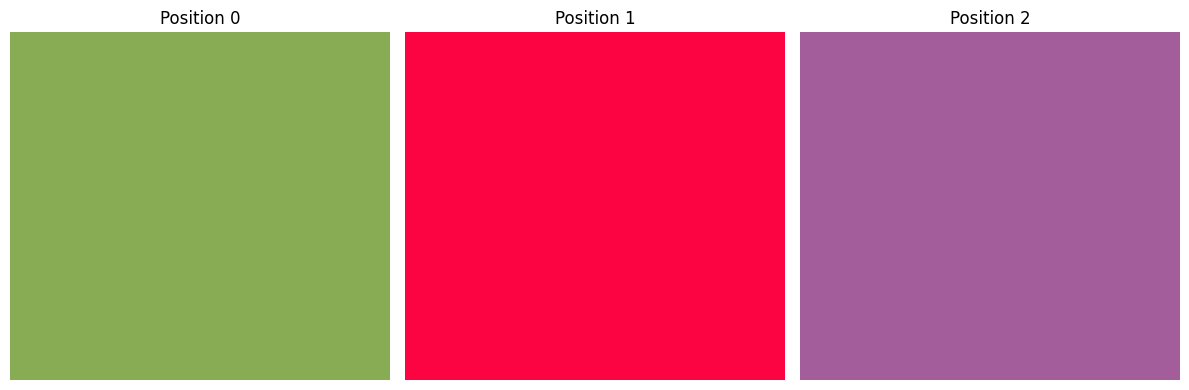

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from colorsys import hls_to_rgb

# Raw content
raw_content = """
[[307.0, 50.0, 27.0], [345.0, 50.0, 98.0], [85.0, 50.0, 35.0]] -> gray -> [[85.0, 50.0, 35.0], [345.0, 50.0, 98.0], [307.0, 50.0, 27.0]] -> 0 -> 2
"""
# [[307.0, 50.0, 27.0], [345.0, 50.0, 98.0], [85.0, 50.0, 35.0]] -> purple -> [[85.0, 50.0, 35.0], [345.0, 50.0, 98.0], [307.0, 50.0, 27.0]] -> 2 -> 2
# human: "[307, 50, 27]","[345, 50, 98]","[85, 50, 35]","[85, 50, 35]","[345, 50, 98]","[307, 50, 27]",2,pink

# look at a sample starts badly at the begining of RL and then gradually improves
def parse_hls_data(raw_data):
    """Parse raw HLS color data from the input string."""
    segments = raw_data.split('->')
    original_data = eval(segments[0].strip())  # Extract and evaluate the first list
    transformed_data = eval(segments[2].strip())  # Extract and evaluate the second list
    return original_data, transformed_data

# Parse the raw content
original_hls, transformed_hls = parse_hls_data(raw_content)
print(f"transformed_hls: {transformed_hls}")

# Normalize HLS values for visualization
transformed_colors = [[h/360, l/100, s/100] for h, l, s in transformed_hls]

def hls_to_rgb_normalized(h, l, s):
    """Convert normalized HLS to RGB."""
    return hls_to_rgb(h, l, s)

# Convert HLS to RGB for visualization
transformed_rgb = [hls_to_rgb_normalized(*color) for color in transformed_colors]

# Create the plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Visualize transformed colors
for i, color in enumerate(transformed_rgb):
    ax[i].add_patch(Rectangle((0, 0), 1, 1, color=color))
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].axis('off')
    ax[i].set_title(f"Position {i}")

plt.tight_layout()
plt.show()